# The vinyl revival — a quantitative teardown 🔬
### Revenue index vs SPY (CAGR / vol / MDD + an annual-excess *t*) · Newey-West proxy alpha · the collector-carry haircut on NAV · a synthetic revival positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_priced_in%3F: Confirmed](https://img.shields.io/badge/Already_priced_in%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "vinyl is back, ride it": (H₁) the vinyl-revenue *trend* out-grows SPY; (H₂) a buyable proxy carries alpha vs the market; (H₃) a collector strategy survives the transaction + carry cost. We find **H₁ true but untradable** (revenue growth is not a return), **H₂ rejected** (no significant proxy alpha), **H₃ rejected** (negative net of costs) — and the boom is already in the price.

> ⚠️ **Not investment advice — data provenance.** The vinyl index is **hardcoded, cited, approximate** (public RIAA year-end reports — a *labelled proxy for the trend*, and *industry revenue*, never a price). Equity proxies `WMG`, `SPOT`, `UMG.AS`, `SPY` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vinyl_revival import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_vinyl_index()                        # hardcoded, cited, APPROXIMATE proxy
REV = data.vinyl_revenue_musd()                      # raw RIAA $M
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| vinyl-revenue years:", REV.index[0].year, "->", REV.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'vinyl_win': '2010 → 2024', 'vinyl_musd': {2010: 89, 2014: 321, 2018: 419, 2019: 479, 2020: 643, 2021: 1003, 2022: 1225, 2023: 1353, 2024: 1400}, 'vinyl_yoy': {2019: 14.3, 2020: 34.2, 2021: 56.0, 2022: 22.1, 2023: 10.4, 2024: 3.5}, 'vinyl_cagr': 21.75, 'vinyl_vol': 19.5, 'vinyl_sharpe': 1.19, 'vinyl_mdd': -8.1, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': 4.91, 'excess_t': 0.456, 'excess_p': 0.667, 'excess_n': 6, 'vinyl_share': 7.0, 'streaming_share': 84.0, 'wmg_cagr': 2.76, 'wmg_vol': 36.4, 'wmg_sharpe': 0.25, 'wmg_mdd': -52.2, 'wmg_alpha': -11.52, 'wmg_beta': 1.24, 'wmg_t': -1.23, 'wmg_p': 0.223, 'wmg_n': 66, 'spot_cagr': 18.14, 'spot_vol': 46.8, 'spot_sharpe': 0.58, 'spot_mdd': -74.9, 'spot_alpha': 1.98, 'spot_beta': 1.65, 'spot_t': 0.12, 'spot_p': 0.908, 'spot_n': 92, 'umg_cagr': 1.3, 'umg_vol': 27.3, 'umg_sharpe': 0.18, 'umg_mdd': -24.2, 'umg_alpha': -6.44, 'umg_beta': 0.85, 'umg_t': -0.66, 'umg_p': 0.513, 'umg_n': 51, 'spy_cagr': 13.59, 'spy_vol': 16.5, 'spy_sharpe': 0.86, 'spy_mdd': -23.9, 'carry_gross': 21.75, 'carry_spread': -6.89, 'carry_storage': -1.0, 'carry_net': 12.23, 'carry_flat_net': -7.82, 'syn_peak': 596, 'syn_end': 558, 'syn_cagr': 18.86, 'syn_sharpe': 1.28, 'syn_mdd': -15.3}


equity-proxy cache present: True | vinyl-revenue years: 2010 -> 2024


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Vinyl revenue CAGR **21.8%** > SPY **17.2%** (a real trend) — but revenue growth isn't a return; annual excess *t* = **+0.46** (n=6), and no proxy alpha clears |t|≥2 (WMG -1.23, SPOT +0.12, UMG -0.66). |
| **Tradability** | `MIRAGE` | Two proxies *lagged* SPY (WMG +2.8%, UMG +1.3% vs +13.6%); the winner SPOT is β≈1.65 streaming with a -75% drawdown; collector flip nets **-7.8%/yr**. |
| **Already priced in?** | `CONFIRMED` | Vinyl ~7% of a ~84%-streaming business; no vinyl-attributable premium in any listed proxy. A public 18-year trend is not an edge. |

> 💡 In plain words: the revival is genuinely real and even out-grew stocks — but it's a *revenue* trend you can't custody, the only things you can buy are streaming-driven beta with no vinyl alpha, and flipping records loses to costs. "Trade the vinyl trend" is a category error the market already reflects.

## 1 · The claim, steelmanned

Let the vinyl-revenue level be $V_t$ and the benchmark $B_t$ (SPY). The claim is a joint hypothesis:

- **H₁ (the trend out-grows).** Annual excess $\;x_t = r^V_t - r^B_t\;$ has $\mathbb{E}[x_t] > 0$ — vinyl grows faster than stocks. *(Note: $r^V$ is revenue growth, a category measure, not an investable return.)*
- **H₂ (it's buyable with alpha).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₃ (a collector clears costs).** The net CAGR after the marketplace round-trip spread $s$ over hold $h$ and storage carry $c$ stays positive: $(1+g)(1+((1-s)^{1/h}-1))(1-c)-1 > 0$.

The steelman is unusually strong: unlike a bubble, H₁ is *durably* true — 18 consecutive up years. The test is whether **truth of the trend implies a tradable, net-of-cost edge** — i.e. whether "real trend" and "investable" are the same thing. They are not.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, thematic investing would be a free lunch: identify a visible growing trend, buy it, win. But each leg is separately falsifiable. H₁ is a **growth race** on a common clock — and here it's the *plaintiff's best evidence*, because the trend really did out-grow SPY. H₂ asks whether the *only investable expression* (listed equities) delivers anything beyond market beta — because you cannot custody "the revenue series," and vinyl is a single-digit slice of a streaming-dominated P&L. H₃ is the **microstructure tax** on the one *direct* holding (physical records), compounded by a supply response an ETF never faces: a revived market **presses more units**. The tradable claim needs H₂ or H₃; a true H₁ alone is a growing industry you cannot bank.

## 3 · How we'd know — the protocol

- **Vinyl index (proxy).** A hardcoded, cited, **approximate** annual RIAA level (base 100 @ 2010), reconstructed from public year-end reports (CDs overtaken in revenue 2020, in units 2022; ~$1.4B by 2024). *Labelled a proxy* — its path is defensible, its precise values are not a live feed, and it is **revenue, not price**.
- **Equity proxies.** `WMG`, `SPOT`, `UMG.AS`, `SPY` month-end Adj Close (yfinance, cached). Survivorship is **not** a concern (named tickers, not a screen), but each series starts at its **listing date** (SPOT 2018-04, WMG 2020-06, UMG 2021-09) — a real look-ahead caveat (we see only the listed life), stated.
- **Signal test.** (i) Paired annual-excess $t$ of $r^V - r^B$ (small-$n$, and a *growth* not a *return* comparison — weak by construction and by category). (ii) **Newey-West (6-lag) HAC** $t$ of each proxy alpha vs SPY — the bar for `REAL` is *t* ≥ 2 in the trade's favour.
- **Cost (beat 6).** Charge the collector round-trip spread (30% over a 5y hold) + 1%/yr storage **once on NAV**, under both a charitable (records appreciate at revenue growth) and a realistic (flat per-record resale) gross.
- **Positive control.** A deterministic revival path with a *planted* positive drift; the engine must recover the up-sign and a finite Sharpe — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "tradable":** a proxy alpha *t* > 2 **or** a positive net-of-cost collector CAGR. We find neither.

## 4 · The teardown

### 4a · The growth race — vinyl revenue vs SPY

The RIAA revenue index (base 100 @ 2010) on its own clock; SPY year-end for scale. CAGR, vol and the annual-excess *t* in the print. **This is a growth comparison, not a return you can earn.**

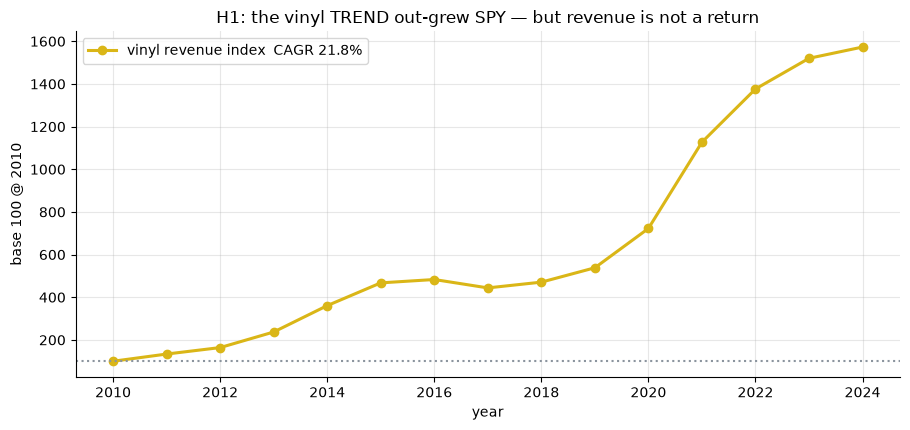

vinyl: CAGR 21.75%  vol 19.5%  maxDD -8.1%
SPY  : CAGR 17.18%  vol 16.9%  maxDD -18.2%
annual excess (vinyl-SPY): mean +4.91%/yr  t=+0.456  (n=6)


In [2]:
yrs = [int(y) for y in IDX.index.year]
lv = np.array([float(v) for v in IDX.values])
si = st.summarize(IDX, periods_per_year=1.0)
if HAVE_PROXIES:
    spy_ye = PROX['SPY'].resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    ss = st.summarize(spy_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(IDX, PROX['SPY'])
else:
    ss = {'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    ae = {'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"vinyl revenue index  CAGR {si['cagr']*100:.1f}%")
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year'); ax.set_ylabel('base 100 @ 2010')
ax.set_title('H1: the vinyl TREND out-grew SPY — but revenue is not a return'); ax.legend()
plt.tight_layout(); plt.show()
print(f"vinyl: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY  : CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (vinyl-SPY): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: vinyl revenue compounded at **21.8%** against SPY's **17.2%** — the trend genuinely *out-grew* stocks. But this is the plaintiff's best exhibit and it still doesn't help: the annual excess is **+4.9%/yr**, *t* = **+0.46** (n=6) — not even a clean growth win — and, decisively, **revenue growth is not an investable return.** There is no security that pays the RIAA series. H₁ is *true and irrelevant*.

### 4b · The buyable proxies — is there alpha, or just beta?

Newey-West (6-lag) regression of each proxy's **monthly** return on SPY. `REAL` needs $t_\alpha \ge 2$ in the trade's favour.

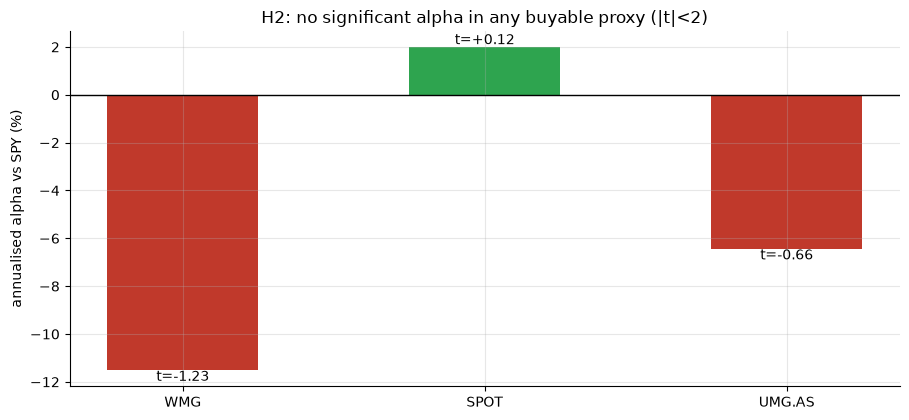

WMG     CAGR   2.76%  Sharpe 0.25  maxDD  -52.2%  alpha -11.52%/yr  beta 1.24  NW t -1.23
SPOT    CAGR  18.14%  Sharpe 0.58  maxDD  -74.9%  alpha +1.98%/yr  beta 1.65  NW t +0.12
UMG.AS  CAGR   1.30%  Sharpe 0.18  maxDD  -24.2%  alpha -6.44%/yr  beta 0.85  NW t -0.66


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['WMG','SPOT','UMG.AS']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'WMG':dict(cagr=R['wmg_cagr'],sharpe=R['wmg_sharpe'],mdd=R['wmg_mdd'],alpha=R['wmg_alpha'],beta=R['wmg_beta'],t=R['wmg_t']),
            'SPOT':dict(cagr=R['spot_cagr'],sharpe=R['spot_sharpe'],mdd=R['spot_mdd'],alpha=R['spot_alpha'],beta=R['spot_beta'],t=R['spot_t']),
            'UMG.AS':dict(cagr=R['umg_cagr'],sharpe=R['umg_sharpe'],mdd=R['umg_mdd'],alpha=R['umg_alpha'],beta=R['umg_beta'],t=R['umg_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H2: no significant alpha in any buyable proxy (|t|<2)')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:6.2f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: the two pure labels carry *negative* point-alpha (WMG -12%/yr, *t*=-1.23; UMG -6%/yr, *t*=-0.66) — they under-performed the market they're exposed to. Spotify's alpha is **+2%/yr but *t*=+0.12** — statistically zero, and it's β≈1.65 *streaming* beta with a -75% drawdown, not vinyl. **None clears |t| ≥ 2**: H₂ rejected. The only investable expressions of the trade are market beta you could have bought cheaper as SPY.

### 4c · The microstructure tax — a collector's net of spread + carry

The one *direct* holding is physical records. A flip pays a ~30% round-trip spread (marketplace fee + condition discount) over a ~5-year hold plus ~1%/yr storage. We show it under two grosses: **charitable** (records appreciate at the full revenue-growth rate) and **realistic** (per-record resale ≈ flat, because a revived market presses more units).

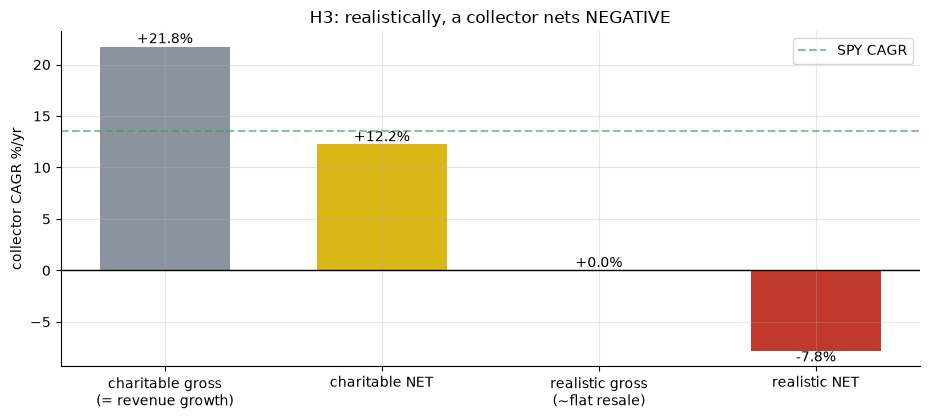

charitable: gross +21.75%  - spread -6.89%/yr  - storage -1.00%/yr  =  NET +12.23%/yr
realistic : gross +0.00%  =>  NET -7.82%/yr


In [4]:
hc = st.net_of_collector_carry(si['cagr'], round_trip_spread=0.30, hold_years=5.0, storage_per_year=0.01)
h0 = st.net_of_collector_carry(0.0, round_trip_spread=0.30, hold_years=5.0, storage_per_year=0.01)
cats = ['charitable gross\n(= revenue growth)', 'charitable NET', 'realistic gross\n(~flat resale)', 'realistic NET']
vals = [hc['gross_cagr']*100, hc['net_cagr']*100, 0.0, h0['net_cagr']*100]
cols = [GREY, AMBER, GREY, RED]
fig, ax = plt.subplots(figsize=(9.4,4.3))
ax.bar(cats, vals, .6, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('collector CAGR %/yr'); ax.set_title('H3: realistically, a collector nets NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print(f"charitable: gross {hc['gross_cagr']*100:+.2f}%  - spread {hc['spread_drag_annual']*100:+.2f}%/yr  - storage {hc['storage_per_year']*100:+.2f}%/yr  =  NET {hc['net_cagr']*100:+.2f}%/yr")
print(f"realistic : gross {h0['gross_cagr']*100:+.2f}%  =>  NET {h0['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: even the *charitable* fantasy (net **+12.2%/yr**) still trails SPY and rests on a false premise — the RIAA line is *industry revenue*, and a booming market **expands supply**, so your specific record does not appreciate at ~22%/yr. On the realistic read (flat resale), the collector nets **-7.8%/yr** after spread + storage. H₃ rejected. **MIRAGE** is the only honest stamp.

### 4d · Positive control — the engine recovers a planted revival

A deterministic revival path (planted +20% CAGR, σ=4%/mo, seed 715). The harness must recover the up-sign and a finite Sharpe — proving the nulls above are real, not a broken pipeline.

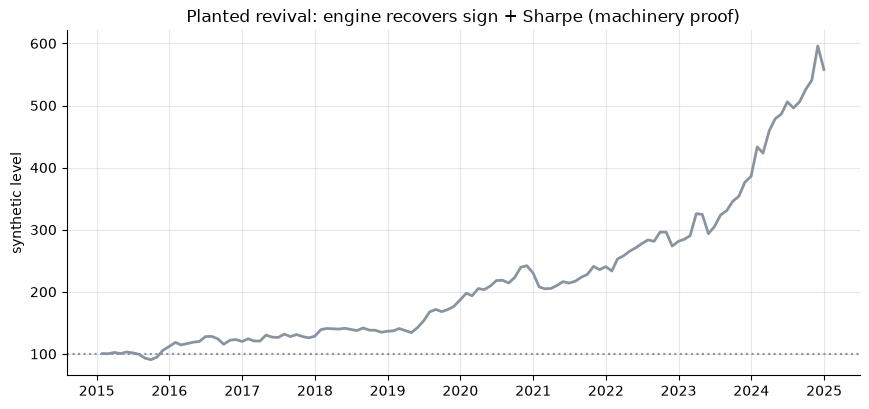

peak 596 -> end 558  recovered CAGR +18.86%  Sharpe 1.28  maxDD -15.3%  sign_ok=1


In [5]:
syn = data.synthetic_revival()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted revival: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR ~+19%, Sharpe ~1.3, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — vinyl revenue CAGR 21.8% > SPY 17.2% (a genuine trend), but revenue growth is not a return, the annual excess is unclean (*t* = +0.46, n=6), and proxy alphas are insignificant (WMG *t*=-1.23, SPOT *t*=+0.12, UMG *t*=-0.66). No robust *t* ≥ 2 anywhere in the trade's favour.
- **Tradability `MIRAGE`** — two proxies lagged SPY (WMG +2.8%, UMG +1.3% vs +13.6%); the winner SPOT is β≈1.65 streaming with a -75% drawdown and zero alpha; a collector nets **-7.8%/yr** once a supply-expanding market meets the spread.
- **Already priced in? `CONFIRMED`** — vinyl is ~7% of a ~84%-streaming business; no listed proxy carries a vinyl-attributable premium. A famous, public, 18-year trend is not a secret you can trade.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested at each proxy's listing, vs SPY, and the collector path (realistic net from 4c). Capacity is the other wall: the *labels* are liquid but aren't "vinyl," and the *records* are a bespoke, illiquid, ~30%-spread market with no scalable book.

C:\Users\loutr\AppData\Local\Temp\ipykernel_20196\2111333173.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_ylabel('value of $10,000 after 7 years'); ax.set_xticklabels(labels, rotation=12, ha='right')


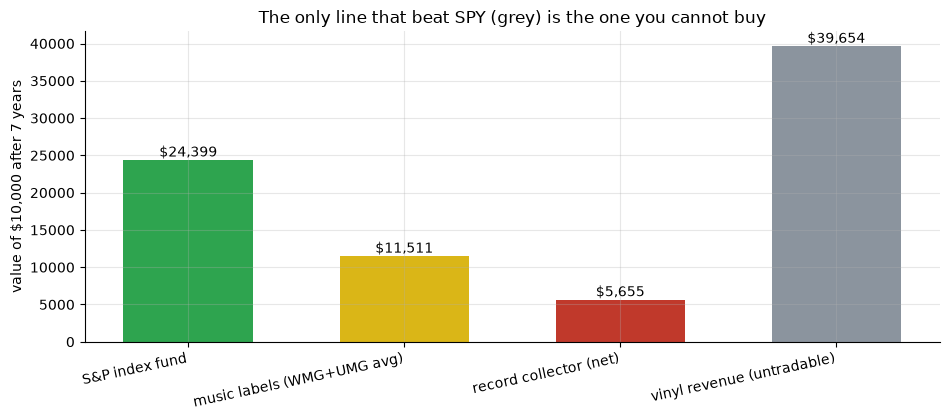

S&P index fund                 $    24,399  (+13.6%/yr)
music labels (WMG+UMG avg)     $    11,511  (+2.0%/yr)
record collector (net)         $     5,655  (-7.8%/yr)
vinyl revenue (untradable)     $    39,654  (+21.8%/yr)


In [6]:
start=10_000.0; yrs_h=7
paths={'S&P index fund':R['spy_cagr']/100, 'music labels (WMG+UMG avg)':(R['wmg_cagr']+R['umg_cagr'])/2/100,
       'record collector (net)':R['carry_flat_net']/100, 'vinyl revenue (untradable)':R['vinyl_cagr']/100}
fig, ax = plt.subplots(figsize=(9.6,4.3))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, AMBER, RED, GREY]
ax.bar(labels, ends, .6, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years'); ax.set_xticklabels(labels, rotation=12, ha='right')
ax.set_title('The only line that beat SPY (grey) is the one you cannot buy')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:30s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: the *untradable* revenue line (grey) is the only one that beats the S&P — and you cannot buy it. The tradable label basket trails; the collector ends below the stake. Capacity seals it: buying labels dilutes vinyl into single-digit-percent of a streaming P&L, and the physical market is a ~30%-round-trip, one-off illiquid trade. There is no venue or size that turns a real trend into an edge.

## 7 · Going further

- **Swap in the live RIAA series.** Replace the hardcoded levels with the exact RIAA year-end figures and re-run; the *t*-stats shift a hair but the sign and the category error (revenue ≠ return) don't move.
- **Per-pressing dispersion.** The aggregate hides survivorship: test individual records on Discogs (a rare first-press vs a current reissue) — the winners are a thin selected tail and a revived market floods supply, so correct for both.
- **The thematic-investing prior.** A real, visible trend (EVs, cannabis, AI, vinyl) is public information; efficient-markets logic says it's in the price before you arrive ([docs/references.md](../docs/references.md)). Vinyl is a clean demonstration.

*The reproducible core is offline and deterministic; the vinyl index is a **cited, approximate proxy** for industry revenue and the equity tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*